In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [22]:
# importing the dataframe

EPL25_26=pd.read_excel('C:/Users/LENOVO/Downloads/league-chemp.xlsx')
display(EPL25_26)

,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Arsenal,38,26,7,5,71,27,85,77.49,33.13,79.87
1,2,Manchester City,38,23,9,6,77,35,78,79.36,46.49,73.95
2,3,Manchester United,38,20,11,7,69,50,71,72.19,50.28,64.45
3,4,Aston Villa,38,19,8,11,56,49,65,56.20,56.68,51.07
4,5,Liverpool,38,17,9,12,63,53,60,67.26,53.87,61.54
5,6,Bournemouth,38,13,18,7,58,54,57,66.83,56.77,60.33
6,7,Sunderland,38,14,12,12,42,48,54,43.14,60.34,42.03
7,8,Brighton,38,14,11,13,52,46,53,58.42,53.75,55.35
8,9,Brentford,38,14,11,13,55,52,53,66.26,59.11,57.24
9,10,Chelsea,38,14,10,14,58,52,52,72.21,58.12,58.85


In [28]:
# calculating new columns

EPL25_26['xG_diff']=EPL25_26['goals']-EPL25_26['xG']
EPL25_26['xGA_diff']=EPL25_26['xGA']-EPL25_26['ga']
EPL25_26['xPTS_diff']=EPL25_26['points']-EPL25_26['xPTS']

# finding out over/underperformers

EPL25_26[['team','goals','xG','xG_diff']].sort_values('xG_diff',ascending=False)
EPL25_26[['team','ga','xGA','xGA_diff']].sort_values('xGA_diff',ascending=False)
EPL25_26[['team','points','xPTS','xPTS_diff']].sort_values('xPTS_diff',ascending=False)

,team,points,xPTS,xPTS_diff
3,Aston Villa,65,51.07,13.93
6,Sunderland,54,42.03,11.97
10,Fulham,52,45.08,6.92
2,Manchester United,71,64.45,6.55
0,Arsenal,85,79.87,5.13
1,Manchester City,78,73.95,4.05
12,Everton,49,46.17,2.83
15,Nottingham Forest,44,42.24,1.76
4,Liverpool,60,61.54,-1.54
18,Burnley,22,24.31,-2.31


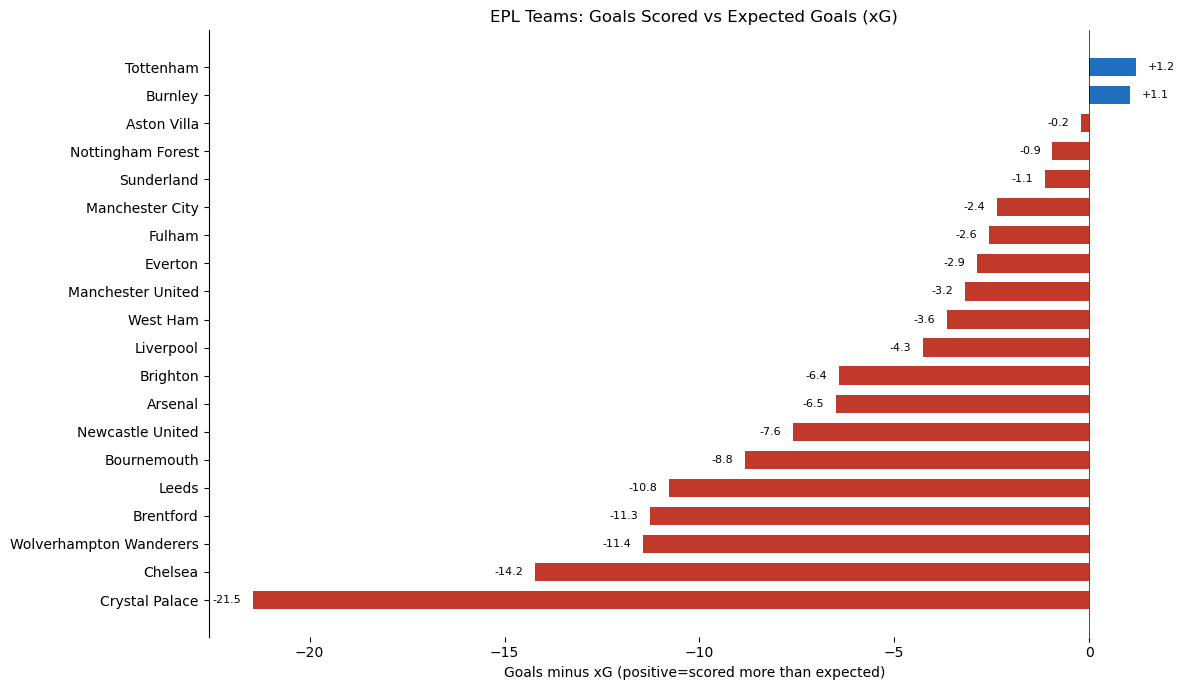

In [58]:
# charts Goals vs xG

EPL25_26_sorted=EPL25_26.sort_values('xG_diff',ascending=True).reset_index(drop=True)
colors=['#C0392B' if x < 0 else '#1F6FBF' for x in EPL25_26_sorted['xG_diff']]

# creating the frame & canvas
fig,ax=plt.subplots(figsize=(12,7))

# drawing bars on the canvas
bars=ax.barh(EPL25_26_sorted['team'],EPL25_26_sorted['xG_diff'],color=colors,height=0.65)

# removing top, right and bottom borders
ax.spines[['top','right','bottom']].set_visible(False)

# adding value labels on each bar
for bar,val in zip(bars,EPL25_26_sorted['xG_diff']):
    ax.text(
        val+(0.3 if val >=0 else -0.3),
        bar.get_y()+bar.get_height()/2,
        f'{val:+.1f}',
        va='center',
        ha='left' if val >=0 else 'right',
        fontsize=8
    )

# adding a title
ax.set_title('EPL Teams: Goals Scored vs Expected Goals (xG)')

# drawing a line on the canvas
ax.axvline(0,color='black',linewidth=0.5)

# axis label
ax.set_xlabel('Goals minus xG (positive=scored more than expected)')

# adjustments
plt.tight_layout()

# saving as an image
plt.savefig('C:/Users/LENOVO/Downloads/epl_xg_analysis.jpg',dpi=150,bbox_inches='tight')

plt.show()

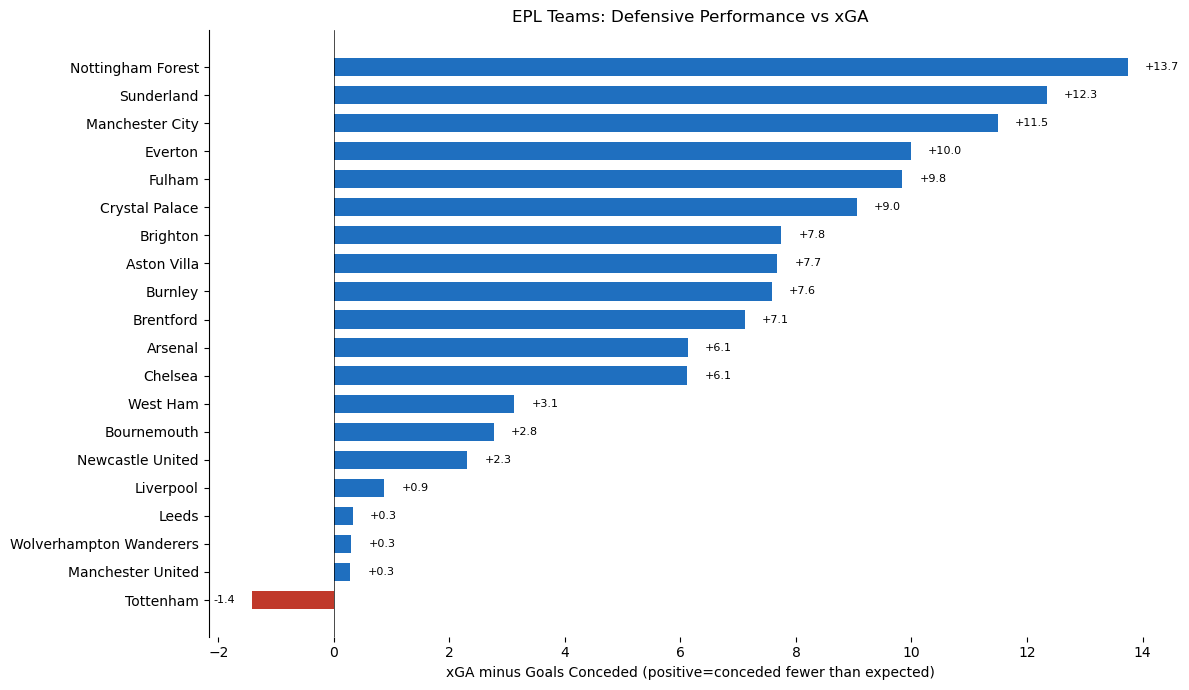

In [61]:
# charts xGA vs goals against

EPL25_26_def=EPL25_26.sort_values('xGA_diff',ascending=True).reset_index(drop=True)
colors=['#C0392B' if x < 0 else '#1F6FBF' for x in EPL25_26_def['xGA_diff']]

# creating the frame & canvas
fig,ax=plt.subplots(figsize=(12,7))

# drawing bars on the canvas
bars2=ax.barh(EPL25_26_def['team'],EPL25_26_def['xGA_diff'],color=colors,height=0.65)

# removing top, right and bottom borders
ax.spines[['top','right','bottom']].set_visible(False)

# adding value labels on each bar
for bar,val in zip(bars2,EPL25_26_def['xGA_diff']):
    ax.text(
        val+(0.3 if val >=0 else -0.3),
        bar.get_y()+bar.get_height()/2,
        f'{val:+.1f}',
        va='center',
        ha='left' if val >=0 else 'right',
        fontsize=8
    )

# adding a title
ax.set_title('EPL Teams: Defensive Performance vs xGA')

# drawing a line on the canvas
ax.axvline(0,color='black',linewidth=0.5)

# axis label
ax.set_xlabel('xGA minus Goals Conceded (positive=conceded fewer than expected)')

# adjustments
plt.tight_layout()

# saving as an image
plt.savefig('C:/Users/LENOVO/Downloads/epl_xga_analysis.jpg',dpi=150,bbox_inches='tight')

plt.show()

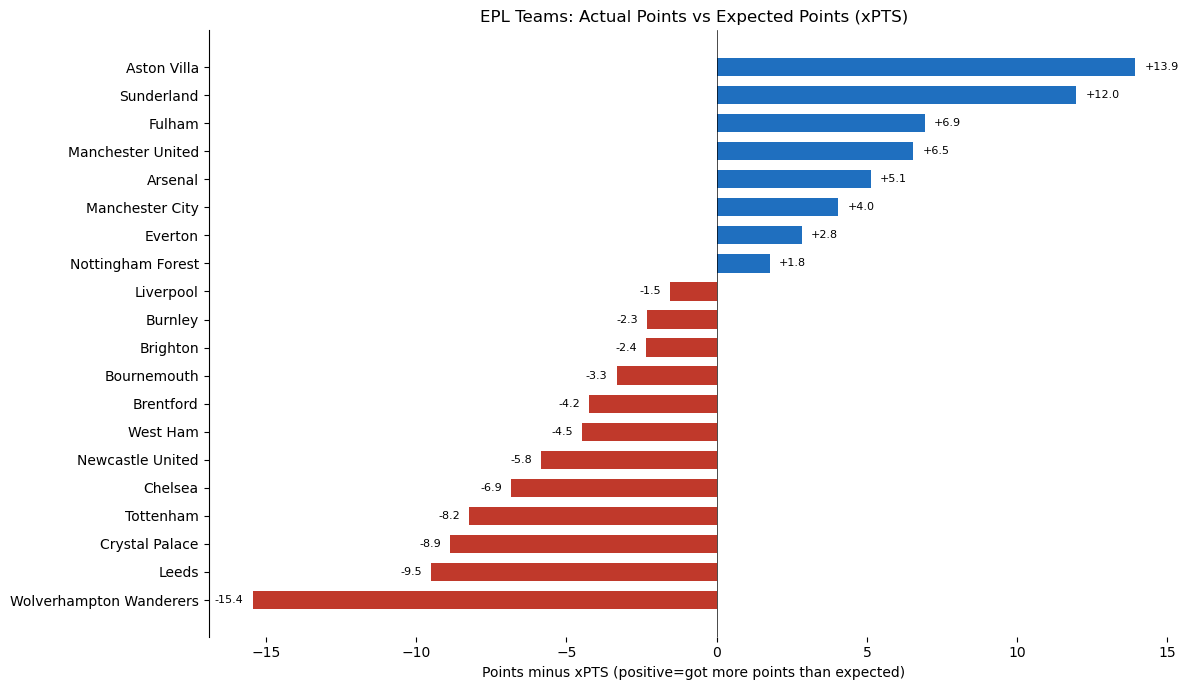

In [64]:
# charts Actual Points vs xPTS

EPL25_26_pts=EPL25_26.sort_values('xPTS_diff',ascending=True).reset_index(drop=True)
colors=['#C0392B' if x < 0 else '#1F6FBF' for x in EPL25_26_pts['xPTS_diff']]

# creating the frame & canvas
fig,ax=plt.subplots(figsize=(12,7))

# drawing bars on the canvas
bars3=ax.barh(EPL25_26_pts['team'],EPL25_26_pts['xPTS_diff'],color=colors,height=0.65)

# removing top, right and bottom borders
ax.spines[['top','right','bottom']].set_visible(False)

# adding value labels on each bar
for bar,val in zip(bars3,EPL25_26_pts['xPTS_diff']):
    ax.text(
        val+(0.3 if val >=0 else -0.3),
        bar.get_y()+bar.get_height()/2,
        f'{val:+.1f}',
        va='center',
        ha='left' if val >=0 else 'right',
        fontsize=8
    )

# adding a title
ax.set_title('EPL Teams: Actual Points vs Expected Points (xPTS)')

# drawing a line on the canvas
ax.axvline(0,color='black',linewidth=0.5)

# axis label
ax.set_xlabel('Points minus xPTS (positive=got more points than expected)')

# adjustments
plt.tight_layout()

# saving as an image
plt.savefig('C:/Users/LENOVO/Downloads/epl_xpts_analysis.jpg',dpi=150,bbox_inches='tight')

plt.show()

In [68]:
# summary

print("=" *55)
print("KEY FINDINGS")
print("=" *55)

print("\n--- ATTACKING: Goals vs xG ---")
print("\nTop 3 Overperformers:")
print(EPL25_26.nlargest(3,'xG_diff')[['team','goals','xG','xG_diff']])
print("\nTop 3 Underperformers:")
print(EPL25_26.nsmallest(3,'xG_diff')[['team','goals','xG','xG_diff']])

print("\n--- DEFENSIVE: xGA vs Goals Conceded ---")
print("\nTop 3 Defensive Overperformers:")
print(EPL25_26.nlargest(3,'xGA_diff')[['team','ga','xGA','xGA_diff']])
print("\nTop 3 Defensive Underperformers:")
print(EPL25_26.nsmallest(3,'xGA_diff')[['team','ga','xGA','xGA_diff']])

print("\n--- OVERALL: Actual Points vs xPTS ---")
print("\nTop 3 Points Overperformers:")
print(EPL25_26.nlargest(3,'xPTS_diff')[['team','points','xPTS','xPTS_diff']])
print("\nTop 3 Points Underperformers:")
print(EPL25_26.nsmallest(3,'xPTS_diff')[['team','points','xPTS','xPTS_diff']])

KEY FINDINGS

--- ATTACKING: Goals vs xG ---

Top 3 Overperformers:
           team  goals     xG  xG_diff
16    Tottenham     48  46.80     1.20
18      Burnley     38  36.94     1.06
3   Aston Villa     56  56.20    -0.20

Top 3 Underperformers:
                       team  goals     xG  xG_diff
14           Crystal Palace     41  62.46   -21.46
9                   Chelsea     58  72.21   -14.21
19  Wolverhampton Wanderers     27  38.44   -11.44

--- DEFENSIVE: xGA vs Goals Conceded ---

Top 3 Defensive Overperformers:
                 team  ga    xGA  xGA_diff
15  Nottingham Forest  51  64.74     13.74
6          Sunderland  48  60.34     12.34
1     Manchester City  35  46.49     11.49

Top 3 Defensive Underperformers:
                       team  ga    xGA  xGA_diff
16                Tottenham  57  55.59     -1.41
2         Manchester United  50  50.28      0.28
19  Wolverhampton Wanderers  68  68.30      0.30

--- OVERALL: Actual Points vs xPTS ---

Top 3 Points Overperformers:
 